# FaceTrace — Face Recognition using VGG16 + ML Classifiers
**Joel Thankachan | MSc Data Science | A00047766**

The idea is simple — extract face embeddings using a pretrained VGG16 model,
then train classical ML classifiers on those embeddings to identify people.

Dataset: Top 10 identities from LFW (~1457 images)  
Classifiers tested: SVM, KNN, Random Forest, Logistic Regression


## 1. Imports

In [2]:
import os
import cv2
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
import keras
from keras.applications import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.models import Model
from keras.layers import GlobalAveragePooling2D

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, f1_score, roc_curve, auc)
from sklearn.utils.class_weight import compute_class_weight
from scipy import stats

print("All imports done")
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)


All imports done
TensorFlow: 2.21.0
Keras: 3.13.2


## 2. Load the Dataset

In [3]:
BASE_PATH     = r"C:\Users\177r1\OneDrive\Desktop\MSC DS Project\FaceTrace_V2\Dataset"
DATASET_PATH  = os.path.join(BASE_PATH, "enrolled")    # enrolled identities
IMPOSTOR_PATH = os.path.join(BASE_PATH, "impostors")   # impostor identities for open-set eval

# Get all class folders
VISUALS_PATH = "Visuals"
os.makedirs(VISUALS_PATH, exist_ok=True)

class_names = sorted(os.listdir(DATASET_PATH))
print("Classes found:", class_names)
print("Total classes:", len(class_names))

# Count images per class
for name in class_names:
    folder = os.path.join(DATASET_PATH, name)
    count = len(os.listdir(folder))
    print(f"  {name}: {count} images")


Classes found: ['Ariel_Sharon', 'Colin_Powell', 'Donald_Rumsfeld', 'George_W_Bush', 'Gerhard_Schroeder', 'Hugo_Chavez', 'Jean_Chretien', 'John_Ashcroft', 'Junichiro_Koizumi', 'Tony_Blair']
Total classes: 10
  Ariel_Sharon: 77 images
  Colin_Powell: 236 images
  Donald_Rumsfeld: 121 images
  George_W_Bush: 530 images
  Gerhard_Schroeder: 109 images
  Hugo_Chavez: 71 images
  Jean_Chretien: 55 images
  John_Ashcroft: 53 images
  Junichiro_Koizumi: 60 images
  Tony_Blair: 144 images


## 3. Class Distribution

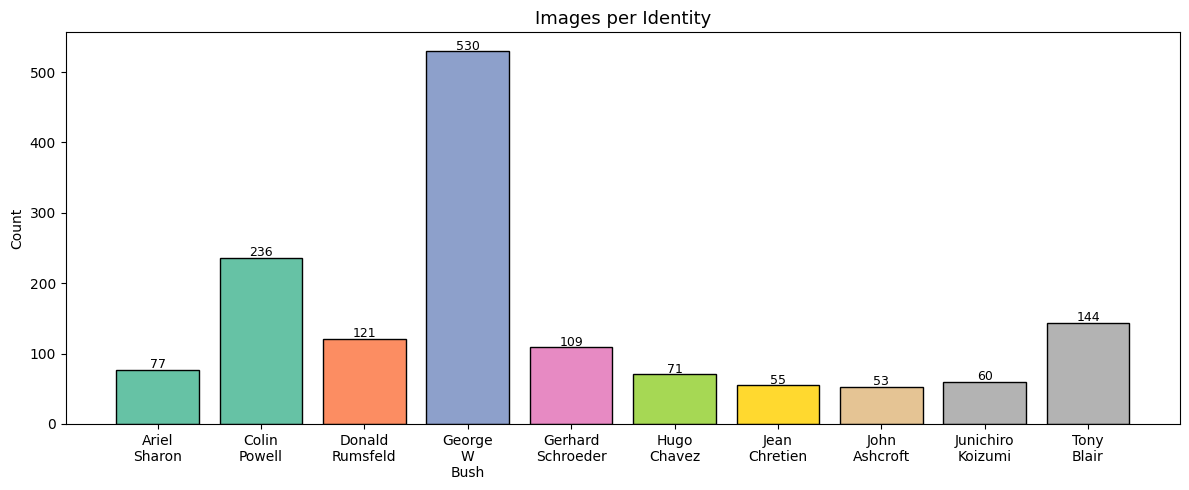

Saved: Visuals/01_class_distribution.png


In [4]:
counts = []
for name in class_names:
    folder = os.path.join(DATASET_PATH, name)
    counts.append(len(os.listdir(folder)))

plt.figure(figsize=(12, 5))
bars = plt.bar([n.replace("_", "\n") for n in class_names], counts,
               color=plt.cm.Set2(np.linspace(0, 1, len(class_names))),
               edgecolor='black')

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2, str(count), ha='center', fontsize=9)

plt.title("Images per Identity", fontsize=13)
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(VISUALS_PATH, "01_class_distribution.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Visuals/01_class_distribution.png")


## 4. Sample Images

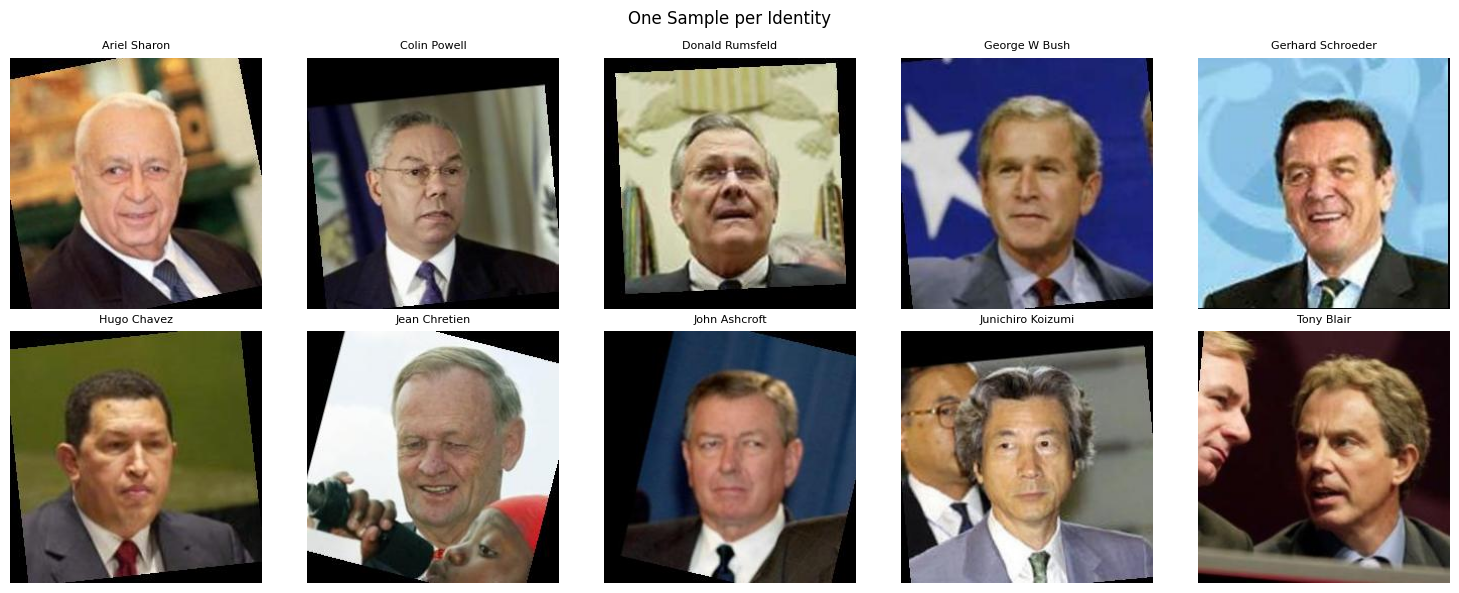

Saved: Visuals/02_sample_images.png


In [5]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, name in enumerate(class_names):
    folder = os.path.join(DATASET_PATH, name)
    img_file = os.listdir(folder)[0]
    img = cv2.imread(os.path.join(folder, img_file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(name.replace("_", " "), fontsize=8)
    axes[i].axis('off')

plt.suptitle("One Sample per Identity", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(VISUALS_PATH, "02_sample_images.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Visuals/02_sample_images.png")


## 5. Face Detection Setup

Using the OpenCV DNN face detector (ResNet-10 SSD) — more reliable than Haar Cascade.
Run the cell below once to load the model files.


In [6]:
face_net = cv2.dnn.readNetFromCaffe(
    r"C:\Users\177r1\OneDrive\Desktop\MSC DS Project\FaceTrace_V2\opencv\deploy.prototxt",
    r"C:\Users\177r1\OneDrive\Desktop\MSC DS Project\FaceTrace_V2\opencv\res10_300x300_ssd_iter_140000.caffemodel"
)
print("Face detector loaded ✓")

Face detector loaded ✓


In [7]:
def get_face(img):
    # detect and return the face crop, or the full image if no face found
    h, w = img.shape[:2]
    blob = cv2.dnn.blobFromImage(cv2.resize(img, (300, 300)), 1.0,
                                  (300, 300), (104.0, 177.0, 123.0))
    face_net.setInput(blob)
    detections = face_net.forward()

    best_conf = 0
    best_box = None

    for i in range(detections.shape[2]):
        conf = float(detections[0, 0, i, 2])
        if conf > 0.5 and conf > best_conf:
            best_conf = conf
            x1 = max(0, int(detections[0, 0, i, 3] * w))
            y1 = max(0, int(detections[0, 0, i, 4] * h))
            x2 = min(w, int(detections[0, 0, i, 5] * w))
            y2 = min(h, int(detections[0, 0, i, 6] * h))
            best_box = (x1, y1, x2, y2)

    if best_box:
        x1, y1, x2, y2 = best_box
        return img[y1:y2, x1:x2]
    return img   # return full image if no face detected


print("get_face() function ready")


get_face() function ready


## 6. Load VGG16 Embedding Model

We use VGG16 pretrained on ImageNet as a fixed feature extractor.
Removing the top layer and adding GlobalAveragePooling gives a 512-dim face embedding per image.
All weights are frozen — we're not training the CNN at all.


In [ ]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

x = GlobalAveragePooling2D()(base_model.output)
embedding_model = Model(inputs=base_model.input, outputs=x)

for layer in embedding_model.layers:
    layer.trainable = False     # freezes the layer while training

print("VGG16 embedding model loaded ✓")
print("Output shape:", embedding_model.output_shape)
print("Total params:", f"{embedding_model.count_params():,} (all frozen)")


VGG16 embedding model loaded ✓
Output shape: (None, 512)
Total params: 14,714,688 (all frozen)


## 7. Extract Embeddings

Run each image through the frozen VGG16 to get a 512-dim vector.
We save the result to disk so we don't have to re-run this every time.


In [ ]:
EMBEDDINGS_SAVE_PATH = "face_embeddings.npz"

if os.path.exists(EMBEDDINGS_SAVE_PATH):
    print("Loading saved embeddings from disk...")
    data = np.load(EMBEDDINGS_SAVE_PATH)
    X = data['X']
    y = data['y']
    print(f"Loaded {len(X)} embeddings, shape: {X.shape}")

else:
    print("Extracting embeddings — this takes a few minutes...")
    X = []
    y = []

    for label, name in enumerate(class_names):
        folder = os.path.join(DATASET_PATH, name)
        images = os.listdir(folder)
        print(f"  Processing {name} ({len(images)} images)...")

        for img_file in images:
            img_path = os.path.join(folder, img_file)
            img = cv2.imread(img_path)
            if img is None:
                continue

            face = get_face(img)
            face = cv2.resize(face, (224, 224))
            face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
            face = np.expand_dims(face.astype(np.float32), axis=0)
            face = preprocess_input(face)   # Pixel normalisation

            emb = embedding_model.predict(face, verbose=0)
            X.append(emb[0])
            y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)

    np.savez_compressed(EMBEDDINGS_SAVE_PATH, X=X, y=y)
    print(f"\nDone! Saved {len(X)} embeddings to {EMBEDDINGS_SAVE_PATH}")

print("\nEmbedding matrix shape:", X.shape)
print("Label array shape:", y.shape)


Loading saved embeddings from disk...
Loaded 1456 embeddings, shape: (1456, 512)

Embedding matrix shape: (1456, 512)
Label array shape: (1456,)


## 7b. Extract Impostor Embeddings

Extract VGG16 embeddings for the impostor set (identities outside the enrolled 10).
These will be used later for true open-set FAR evaluation — testing whether the system
correctly rejects faces it has never seen during training.


In [11]:
IMPOSTOR_EMBEDDINGS_PATH = "impostor_embeddings.npz"

impostor_names = sorted(os.listdir(IMPOSTOR_PATH))
print("Impostors found:", impostor_names)

if os.path.exists(IMPOSTOR_EMBEDDINGS_PATH):
    print("Loading saved impostor embeddings...")
    imp_data = np.load(IMPOSTOR_EMBEDDINGS_PATH)
    X_imp = imp_data['X']
    y_imp = imp_data['y']
    print(f"Loaded {len(X_imp)} impostor embeddings, shape: {X_imp.shape}")

else:
    print("Extracting impostor embeddings...")
    X_imp = []
    y_imp = []

    for label, name in enumerate(impostor_names):
        folder = os.path.join(IMPOSTOR_PATH, name)
        images = os.listdir(folder)
        print(f"  Processing {name} ({len(images)} images)...")

        for img_file in images:
            img_path = os.path.join(folder, img_file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            face = get_face(img)
            face = cv2.resize(face, (224, 224))
            face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
            face = np.expand_dims(face.astype(np.float32), axis=0)
            face = preprocess_input(face)
            emb  = embedding_model.predict(face, verbose=0)
            X_imp.append(emb[0])
            y_imp.append(label)

    X_imp = np.array(X_imp, dtype=np.float32)
    y_imp = np.array(y_imp, dtype=np.int32)
    np.savez_compressed(IMPOSTOR_EMBEDDINGS_PATH, X=X_imp, y=y_imp)
    print(f"Done! Saved {len(X_imp)} impostor embeddings.")

print(f"Impostor embedding matrix shape: {X_imp.shape}")


Impostors found: ['Arnold_Schwarzenegger', 'Gloria_Macapagal_Arroyo', 'Jacques_Chirac', 'Jennifer_Aniston', 'Laura_Bush', 'Lleyton_Hewitt', 'Luiz_Inacio_Lula_da_Silva', 'Serena_Williams', 'Vladimir_Putin', 'Winona_Ryder']
Loading saved impostor embeddings...
Loaded 414 impostor embeddings, shape: (414, 512)
Impostor embedding matrix shape: (414, 512)


## 8. Train / Validation / Test Split (70 / 15 / 15)

Stratified split to keep class proportions balanced across all three sets.
Test set is locked away until final evaluation — not used for any tuning decisions.


In [12]:
# First split off 15% as the final test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# Split the remaining 85% into train (70%) and val (15%)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15/0.85,
    stratify=y_trainval,
    random_state=42
)

print("Split summary:")
print(f"  Train : {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Val   : {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test  : {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")


Split summary:
  Train : 1018 samples (69.9%)
  Val   : 219 samples (15.0%)
  Test  : 219 samples (15.0%)


## 9. Train Classifiers with GridSearchCV

All four classifiers use the same pipeline: StandardScaler → Classifier.
GridSearchCV with 5-fold stratified CV tunes hyperparameters automatically.
Scoring is macro-averaged F1 to handle the class imbalance fairly.


In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "SVM": {
        "clf": SVC(probability=True, class_weight='balanced', random_state=42),
        "params": {
            "clf__C": [0.1, 1, 10, 100],
            "clf__gamma": ["scale", "auto"],
            "clf__kernel": ["rbf"]
        }
    },
    "KNN": {
        "clf": KNeighborsClassifier(),
        "params": {
            "clf__n_neighbors": [3, 5, 7, 11],
            "clf__weights": ["uniform", "distance"]
        }
    },
    "Random Forest": {
        "clf": RandomForestClassifier(class_weight='balanced', random_state=42),
        "params": {
            "clf__n_estimators": [100, 200, 300],
            "clf__max_depth": [None, 20, 40]
        }
    },
    "Logistic Regression": {
        "clf": LogisticRegression(max_iter=5000, class_weight='balanced',
                                  random_state=42),
        "params": {
            "clf__C": [0.01, 0.1, 1, 10]
        }
    }
}

trained = {}
results = []

for name, config in models.items():
    print(f"Training {name}...")

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", config["clf"])
    ])

    gs = GridSearchCV(pipe, config["params"], scoring="f1_macro",
                      cv=skf, n_jobs=-1, refit=True)
    gs.fit(X_train, y_train)

    trained[name] = gs.best_estimator_

    y_pred = gs.predict(X_val)
    val_f1  = f1_score(y_val, y_pred, average='macro')
    val_acc = accuracy_score(y_val, y_pred)

    results.append({
        "Model": name,
        "CV F1": round(gs.best_score_, 4),
        "Val F1": round(val_f1, 4),
        "Val Accuracy": round(val_acc, 4)
    })

    print(f"  CV F1: {gs.best_score_:.4f} | Val F1: {val_f1:.4f} | Val Acc: {val_acc:.4f}")
    print(f"  Best params: {gs.best_params_}\n")

results_df = pd.DataFrame(results).sort_values("Val F1", ascending=False).reset_index(drop=True)
print("\n--- Summary ---")
print(results_df.to_string(index=False))


Training SVM...


  CV F1: 0.7780 | Val F1: 0.8596 | Val Acc: 0.8904
  Best params: {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}

Training KNN...
  CV F1: 0.5924 | Val F1: 0.7023 | Val Acc: 0.7671
  Best params: {'clf__n_neighbors': 5, 'clf__weights': 'distance'}

Training Random Forest...
  CV F1: 0.3520 | Val F1: 0.3772 | Val Acc: 0.5753
  Best params: {'clf__max_depth': None, 'clf__n_estimators': 100}

Training Logistic Regression...
  CV F1: 0.8790 | Val F1: 0.9264 | Val Acc: 0.9452
  Best params: {'clf__C': 0.1}


--- Summary ---
              Model  CV F1  Val F1  Val Accuracy
Logistic Regression 0.8790  0.9264        0.9452
                SVM 0.7780  0.8596        0.8904
                KNN 0.5924  0.7023        0.7671
      Random Forest 0.3520  0.3772        0.5753


## 9b. Multi-Seed Repeated Experiments + Statistical Testing

To address the single-split limitation, we repeat the train/validation split across
5 different random seeds and report mean ± std for each classifier.
A Wilcoxon signed-rank test determines whether Logistic Regression is
significantly better than each other classifier.


In [14]:
from sklearn.model_selection import RepeatedStratifiedKFold

SEEDS = [42, 0, 1, 7, 99]
seed_results = {name: [] for name in models.keys()}

print("Running multi-seed evaluation...")
for seed in SEEDS:
    X_tr, X_v, y_tr, y_v = train_test_split(
        X, y, test_size=0.15/0.85, stratify=y, random_state=seed
    )
    for name, config in models.items():
        pipe = Pipeline([("scaler", StandardScaler()), ("clf", config["clf"])])
        gs = GridSearchCV(pipe, config["params"], scoring="f1_macro",
                          cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=seed),
                          n_jobs=-1, refit=True)
        gs.fit(X_tr, y_tr)
        val_f1 = f1_score(y_v, gs.predict(X_v), average="macro")
        seed_results[name].append(val_f1)
    print(f"  Seed {seed} done.")

print("--- Multi-Seed Results (Mean ± Std) ---")
ms_rows = []
for name, scores in seed_results.items():
    arr = np.array(scores)
    ms_rows.append({"Model": name, "Mean F1": round(arr.mean(), 4),
                    "Std F1": round(arr.std(), 4), "Min": round(arr.min(), 4),
                    "Max": round(arr.max(), 4)})
    print(f"  {name:<25} Mean={arr.mean():.4f}  Std={arr.std():.4f}")

ms_df = pd.DataFrame(ms_rows).sort_values("Mean F1", ascending=False).reset_index(drop=True)
print("", ms_df.to_string(index=False))


Running multi-seed evaluation...
  Seed 42 done.
  Seed 0 done.
  Seed 1 done.
  Seed 7 done.
  Seed 99 done.
--- Multi-Seed Results (Mean ± Std) ---
  SVM                       Mean=0.8628  Std=0.0297
  KNN                       Mean=0.6285  Std=0.0590
  Random Forest             Mean=0.4132  Std=0.0342
  Logistic Regression       Mean=0.9044  Std=0.0161
               Model  Mean F1  Std F1    Min    Max
Logistic Regression   0.9044  0.0161 0.8828 0.9276
                SVM   0.8628  0.0297 0.8115 0.8935
                KNN   0.6285  0.0590 0.5528 0.7342
      Random Forest   0.4132  0.0342 0.3591 0.4670


In [15]:
# Wilcoxon signed-rank test: LR vs each other classifier
print("--- Statistical Significance Tests (Wilcoxon, LR vs Others) ---")
lr_scores = np.array(seed_results["Logistic Regression"])
stat_rows = []

for name, scores in seed_results.items():
    if name == "Logistic Regression":
        continue
    arr = np.array(scores)
    stat, p = stats.wilcoxon(lr_scores, arr)
    sig = "Yes" if p < 0.05 else "No"
    stat_rows.append({"vs": name, "W-stat": round(stat, 3),
                       "p-value": round(p, 4), "LR better?": sig})
    print(f"  LR vs {name:<20} p={p:.4f}  Significant={sig}")

stat_df = pd.DataFrame(stat_rows)
print("", stat_df.to_string(index=False))


--- Statistical Significance Tests (Wilcoxon, LR vs Others) ---
  LR vs SVM                  p=0.1250  Significant=No
  LR vs KNN                  p=0.0625  Significant=No
  LR vs Random Forest        p=0.0625  Significant=No
            vs  W-stat  p-value LR better?
          SVM     1.0   0.1250         No
          KNN     0.0   0.0625         No
Random Forest     0.0   0.0625         No


Saved: Visuals/09_multiseed_comparison.png


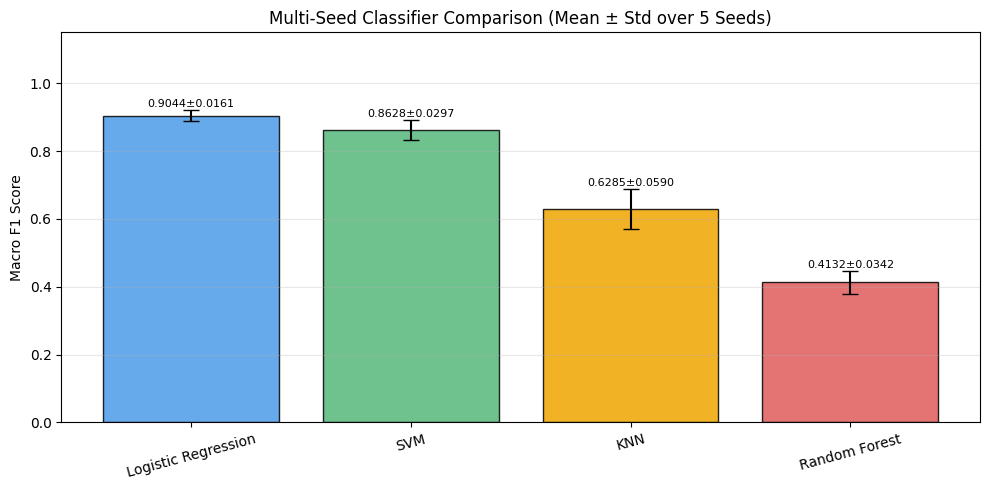

In [16]:
# Multi-seed comparison bar chart with error bars
fig, ax = plt.subplots(figsize=(10, 5))
model_names = ms_df["Model"].tolist()
means = ms_df["Mean F1"].tolist()
stds  = ms_df["Std F1"].tolist()
colours = ["#4C9BE8", "#56B87A", "#F0A500", "#E05C5C"]

bars = ax.bar(model_names, means, yerr=stds, capsize=6,
              color=colours[:len(model_names)], edgecolor="black", alpha=0.85)

for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + s + 0.008,
            f"{m:.4f}±{s:.4f}", ha="center", fontsize=8)

ax.set_title("Multi-Seed Classifier Comparison (Mean ± Std over 5 Seeds)", fontsize=12)
ax.set_ylabel("Macro F1 Score")
ax.set_ylim(0, 1.15)
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(VISUALS_PATH, "09_multiseed_comparison.png"), dpi=150, bbox_inches="tight")
print("Saved: Visuals/09_multiseed_comparison.png")
plt.show()


## 10. Classifier Comparison

Saved: Visuals/03_classifier_comparison.png


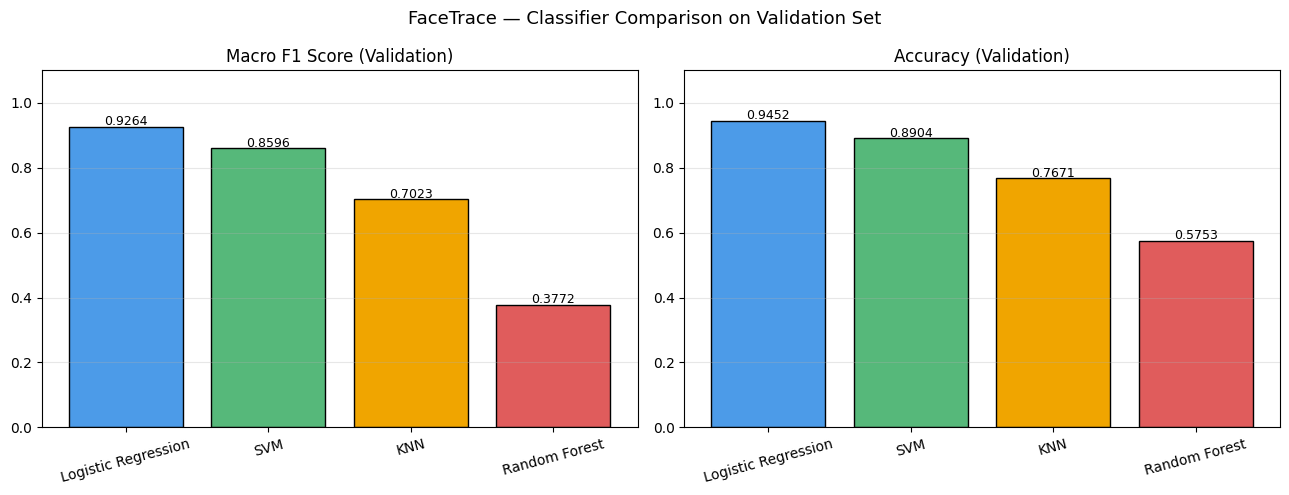

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colours = ['#4C9BE8', '#56B87A', '#F0A500', '#E05C5C']

# F1 chart
axes[0].bar(results_df["Model"], results_df["Val F1"], color=colours, edgecolor='black')
for i, val in enumerate(results_df["Val F1"]):
    axes[0].text(i, val + 0.005, f"{val:.4f}", ha='center', fontsize=9)
axes[0].set_title("Macro F1 Score (Validation)", fontsize=12)
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

# Accuracy chart
axes[1].bar(results_df["Model"], results_df["Val Accuracy"], color=colours, edgecolor='black')
for i, val in enumerate(results_df["Val Accuracy"]):
    axes[1].text(i, val + 0.005, f"{val:.4f}", ha='center', fontsize=9)
axes[1].set_title("Accuracy (Validation)", fontsize=12)
axes[1].set_ylim(0, 1.1)
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("FaceTrace — Classifier Comparison on Validation Set", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(VISUALS_PATH, "03_classifier_comparison.png"), dpi=150, bbox_inches='tight')
print("Saved: Visuals/03_classifier_comparison.png")
plt.show()


## 11. Confusion Matrices (Validation Set)

Saved: Visuals/04_confusion_matrices.png


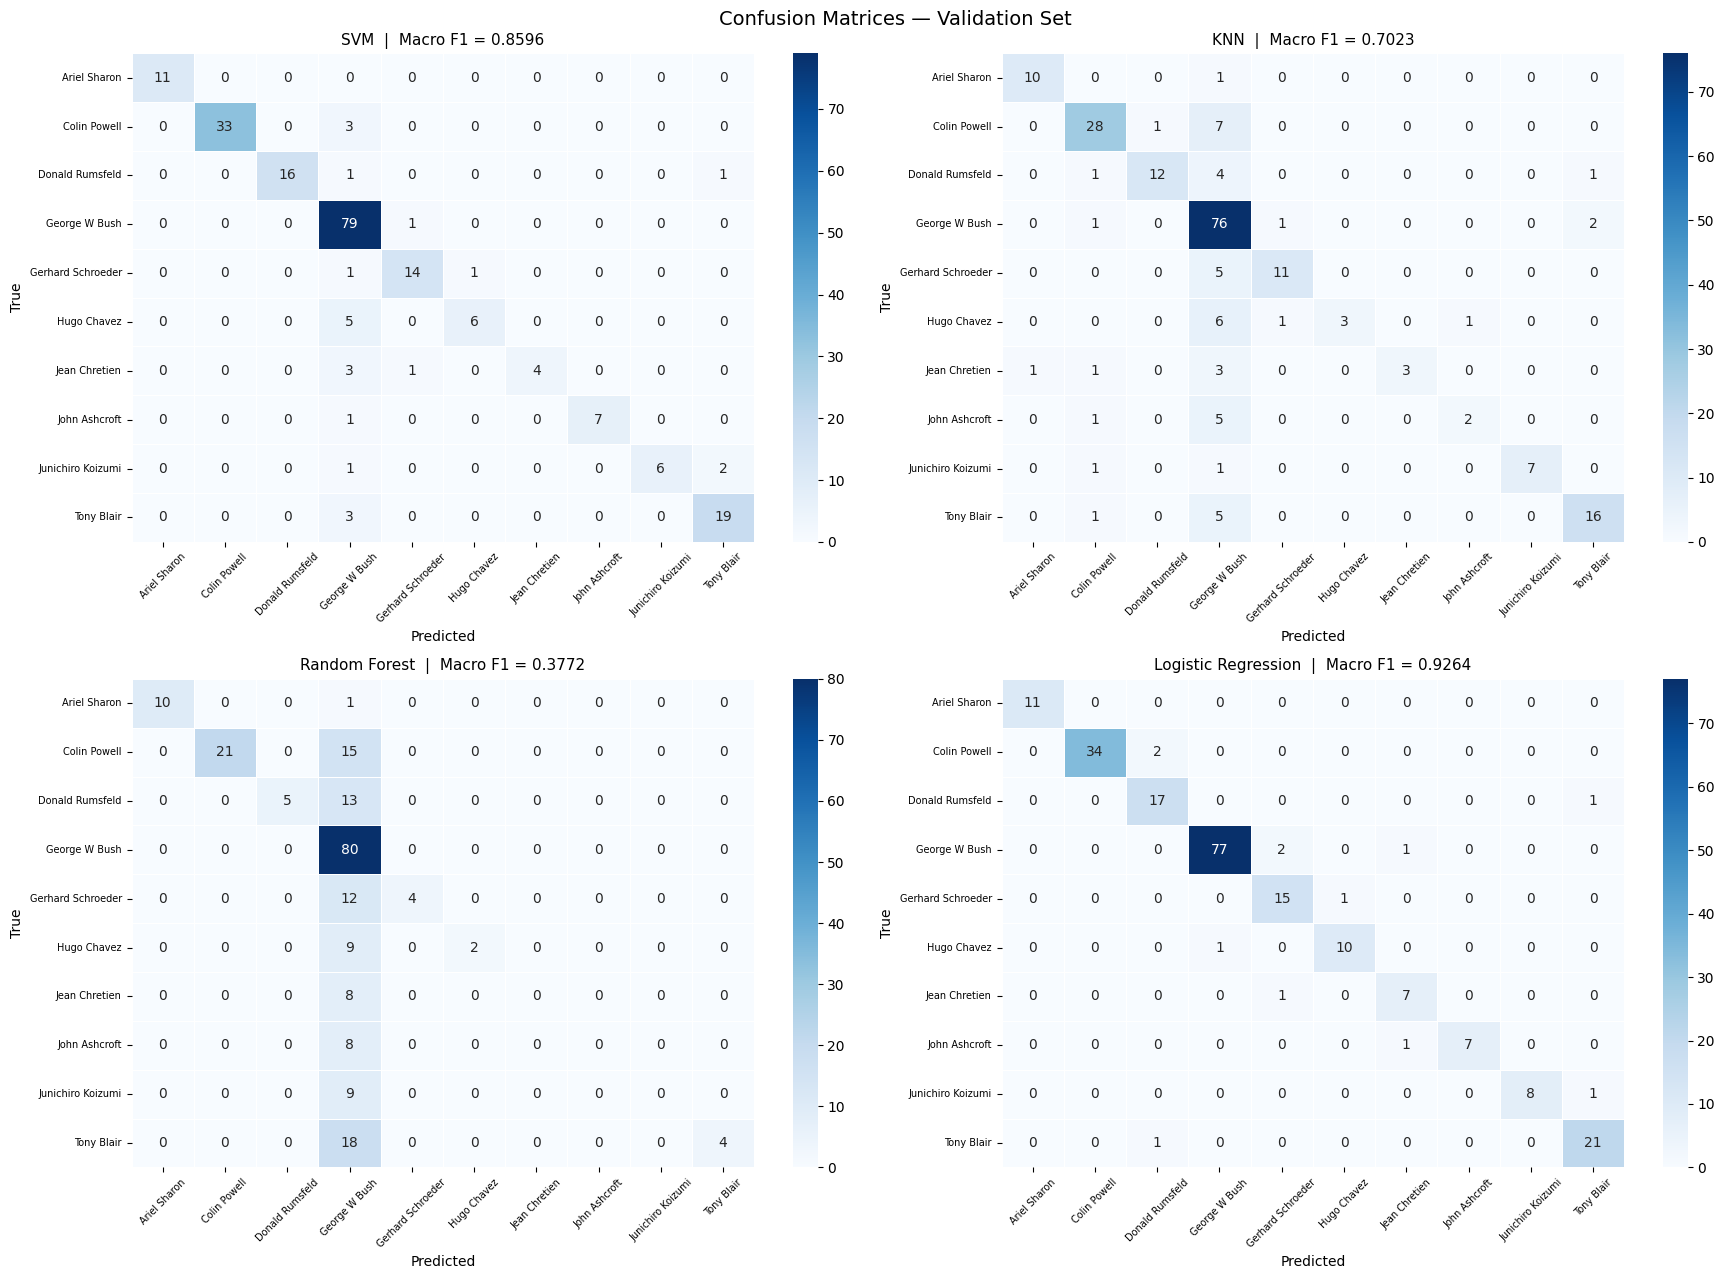

In [18]:
short_names = [n.replace("_", " ") for n in class_names]

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
axes = axes.flatten()

for ax, (name, model) in zip(axes, trained.items()):
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='macro')

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=short_names, yticklabels=short_names,
                linewidths=0.4, ax=ax)
    ax.set_title(f"{name}  |  Macro F1 = {f1:.4f}", fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.suptitle("Confusion Matrices — Validation Set", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(VISUALS_PATH, "04_confusion_matrices.png"), dpi=150, bbox_inches='tight')
print("Saved: Visuals/04_confusion_matrices.png")
plt.show()


## 12. ROC Curves (One-vs-Rest)

Saved: Visuals/05_roc_curves.png


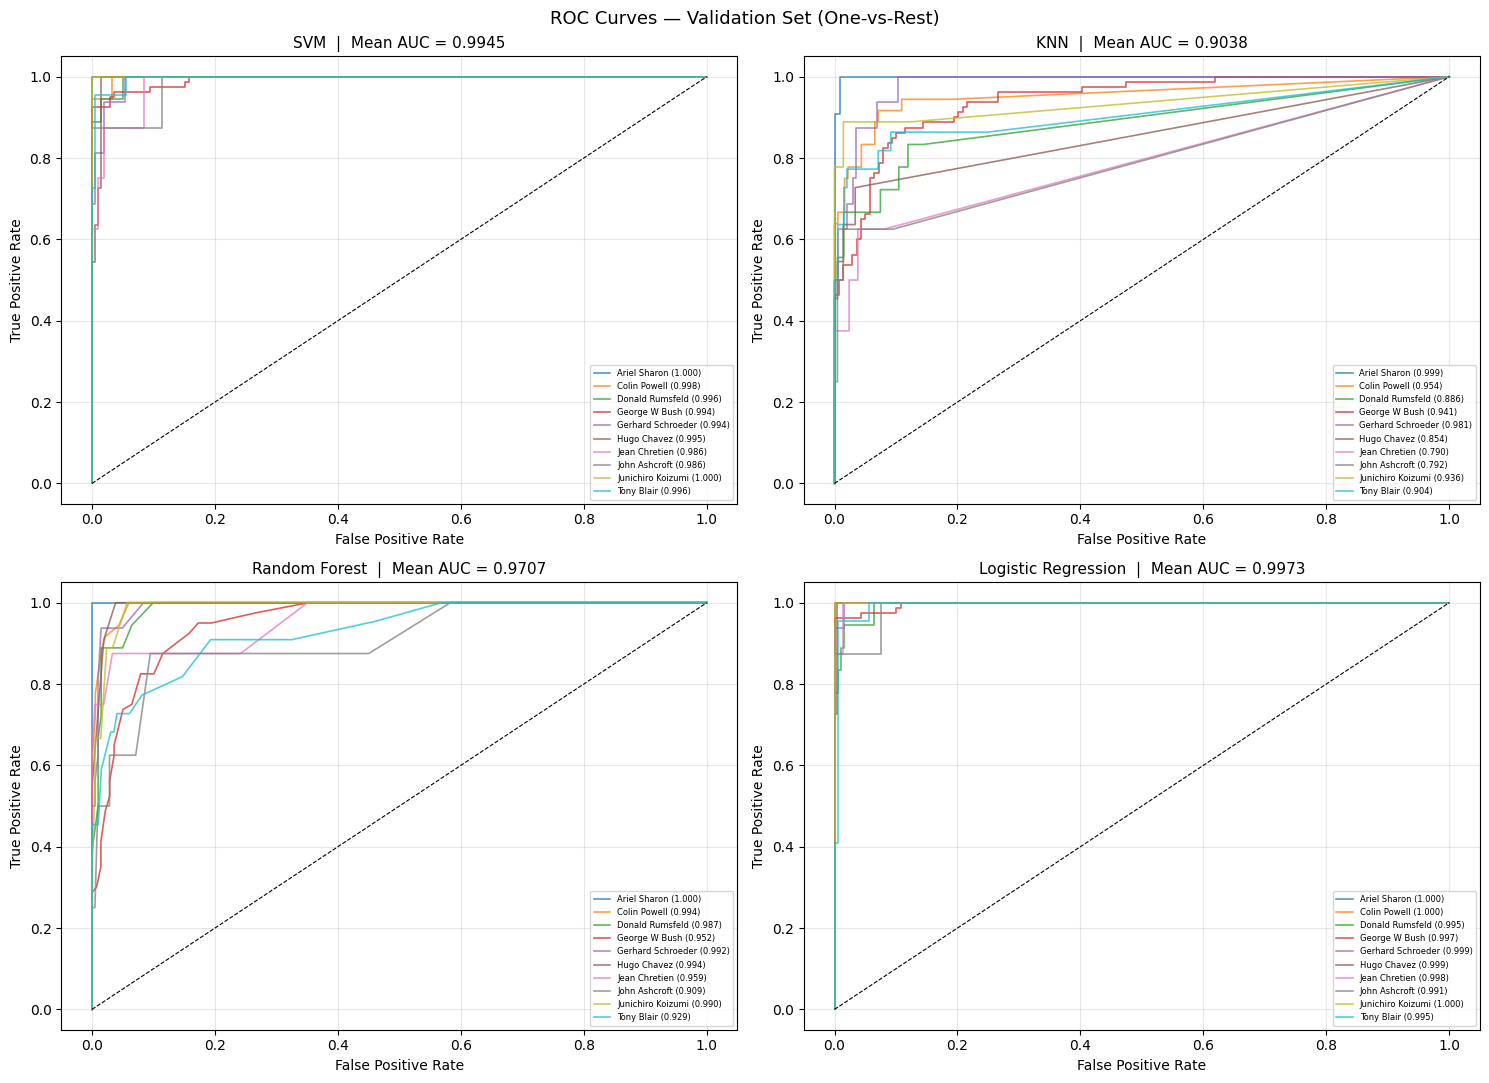

In [19]:
y_val_bin = label_binarize(y_val, classes=list(range(len(class_names))))

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

for ax, (name, model) in zip(axes, trained.items()):
    y_prob = model.predict_proba(X_val)
    auc_scores = []

    for i, cname in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_prob[:, i])
        score = auc(fpr, tpr)
        auc_scores.append(score)
        ax.plot(fpr, tpr, lw=1.2, alpha=0.75,
                label=f"{cname.replace('_', ' ')} ({score:.3f})")

    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_title(f"{name}  |  Mean AUC = {np.mean(auc_scores):.4f}", fontsize=11)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=6, loc='lower right')
    ax.grid(alpha=0.3)

plt.suptitle("ROC Curves — Validation Set (One-vs-Rest)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(VISUALS_PATH, "05_roc_curves.png"), dpi=150, bbox_inches='tight')
print("Saved: Visuals/05_roc_curves.png")
plt.show()


## 13. Pick the Best Model

In [20]:
best_name  = results_df.iloc[0]["Model"]
best_model = trained[best_name]

print(f"Best model: {best_name}")
print(f"Validation F1: {results_df.iloc[0]['Val F1']}")
print(f"Validation Accuracy: {results_df.iloc[0]['Val Accuracy']}")


Best model: Logistic Regression
Validation F1: 0.9264
Validation Accuracy: 0.9452


## 14. True Open-Set FAR / FRR Analysis

We now compute a **true FAR** using the impostor set — faces the classifier
has never seen during training. This gives a genuinely meaningful Equal Error Rate (EER)
rather than one computed only on enrolled identities.

- **FAR (False Acceptance Rate):** Impostors wrongly accepted above the threshold
- **FRR (False Rejection Rate):** Enrolled users wrongly rejected below the threshold


Enrolled validation samples : 219
Impostor samples            : 414
Enrolled confidence  — mean=0.866  std=0.164
Impostor confidence  — mean=0.647  std=0.213
True Open-Set EER : 0.2597
EER Threshold      : 0.829
Saved: Visuals/06_far_frr_curve.png


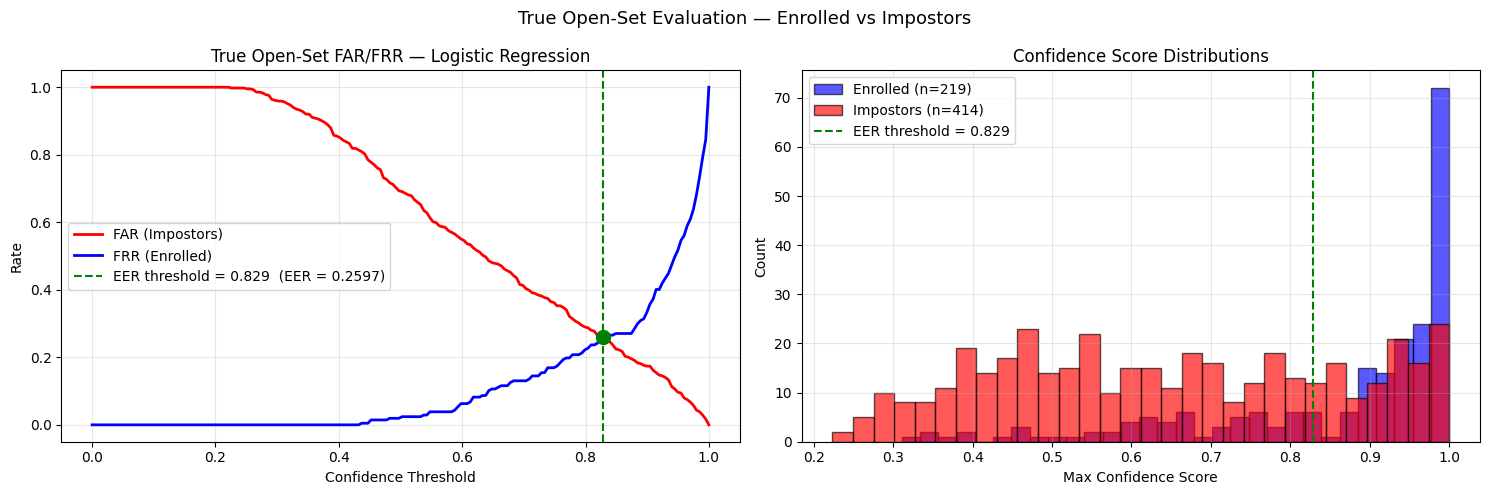

Using rejection threshold: 0.829


In [21]:
# ── Enrolled validation scores (FRR side) ─────────────────────────────────
y_prob_val = best_model.predict_proba(X_val)
y_pred_val = best_model.predict(X_val)
enrolled_max_probs = y_prob_val.max(axis=1)

# ── Impostor scores (FAR side) — truly unseen identities ──────────────────
imp_probs     = best_model.predict_proba(X_imp)
impostor_max_probs = imp_probs.max(axis=1)

print(f"Enrolled validation samples : {len(enrolled_max_probs)}")
print(f"Impostor samples            : {len(impostor_max_probs)}")
print(f"Enrolled confidence  — mean={enrolled_max_probs.mean():.3f}  std={enrolled_max_probs.std():.3f}")
print(f"Impostor confidence  — mean={impostor_max_probs.mean():.3f}  std={impostor_max_probs.std():.3f}")

thresholds = np.linspace(0, 1, 200)
far_list, frr_list = [], []

for thresh in thresholds:
    # True FAR: impostors accepted (confidence >= threshold)
    far = float(np.mean(impostor_max_probs >= thresh))

    # FRR: enrolled correctly predicted but rejected (confidence < threshold)
    correctly_id = (y_pred_val == y_val)
    frr = float(np.mean((enrolled_max_probs < thresh) & correctly_id) /
                max(np.mean(correctly_id), 1e-9))

    far_list.append(far)
    frr_list.append(frr)

far_arr = np.array(far_list)
frr_arr = np.array(frr_list)

eer_idx    = np.argmin(np.abs(far_arr - frr_arr))
eer_thresh = thresholds[eer_idx]
eer_val    = (far_arr[eer_idx] + frr_arr[eer_idx]) / 2

print(f"True Open-Set EER : {eer_val:.4f}")
print(f"EER Threshold      : {eer_thresh:.3f}")

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# FAR/FRR Curve
axes[0].plot(thresholds, far_arr, color="red",  lw=2, label="FAR (Impostors)")
axes[0].plot(thresholds, frr_arr, color="blue", lw=2, label="FRR (Enrolled)")
axes[0].axvline(eer_thresh, color="green", linestyle="--",
                label=f"EER threshold = {eer_thresh:.3f}  (EER = {eer_val:.4f})")
axes[0].scatter([eer_thresh], [eer_val], color="green", s=100, zorder=5)
axes[0].set_title(f"True Open-Set FAR/FRR — {best_name}", fontsize=12)
axes[0].set_xlabel("Confidence Threshold")
axes[0].set_ylabel("Rate")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Confidence score distributions
axes[1].hist(enrolled_max_probs, bins=30, alpha=0.65, color="blue",
             label=f"Enrolled (n={len(enrolled_max_probs)})", edgecolor="black")
axes[1].hist(impostor_max_probs, bins=30, alpha=0.65, color="red",
             label=f"Impostors (n={len(impostor_max_probs)})", edgecolor="black")
axes[1].axvline(eer_thresh, color="green", linestyle="--",
                label=f"EER threshold = {eer_thresh:.3f}")
axes[1].set_title("Confidence Score Distributions", fontsize=12)
axes[1].set_xlabel("Max Confidence Score")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("True Open-Set Evaluation — Enrolled vs Impostors", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(VISUALS_PATH, "06_far_frr_curve.png"), dpi=150, bbox_inches="tight")
print("Saved: Visuals/06_far_frr_curve.png")
plt.show()

REJECTION_THRESHOLD = eer_thresh
print(f"Using rejection threshold: {REJECTION_THRESHOLD:.3f}")


## 15. Final Evaluation on Test Set

The test set hasn't been touched until now — no model or threshold was tuned
using these samples. This gives an honest picture of real-world performance.


In [22]:
y_test_pred = best_model.predict(X_test)

test_f1  = f1_score(y_test, y_test_pred, average='macro')
test_acc = accuracy_score(y_test, y_test_pred)

print("=" * 50)
print(f"  Best Model      : {best_name}")
print(f"  Test Macro F1   : {test_f1:.4f}")
print(f"  Test Accuracy   : {test_acc:.4f}")
print("=" * 50)

print("\nPer-class report:")
print(classification_report(y_test, y_test_pred, target_names=short_names, digits=4))


  Best Model      : Logistic Regression
  Test Macro F1   : 0.9352
  Test Accuracy   : 0.9452

Per-class report:
                   precision    recall  f1-score   support

     Ariel Sharon     0.9167    0.9167    0.9167        12
     Colin Powell     0.9714    0.9714    0.9714        35
  Donald Rumsfeld     0.9000    1.0000    0.9474        18
    George W Bush     0.9744    0.9500    0.9620        80
Gerhard Schroeder     1.0000    0.8750    0.9333        16
      Hugo Chavez     0.8462    1.0000    0.9167        11
    Jean Chretien     0.8889    1.0000    0.9412         8
    John Ashcroft     1.0000    0.8750    0.9333         8
Junichiro Koizumi     1.0000    0.8889    0.9412         9
       Tony Blair     0.8696    0.9091    0.8889        22

         accuracy                         0.9452       219
        macro avg     0.9367    0.9386    0.9352       219
     weighted avg     0.9484    0.9452    0.9454       219



Saved: Visuals/07_test_confusion_matrix.png


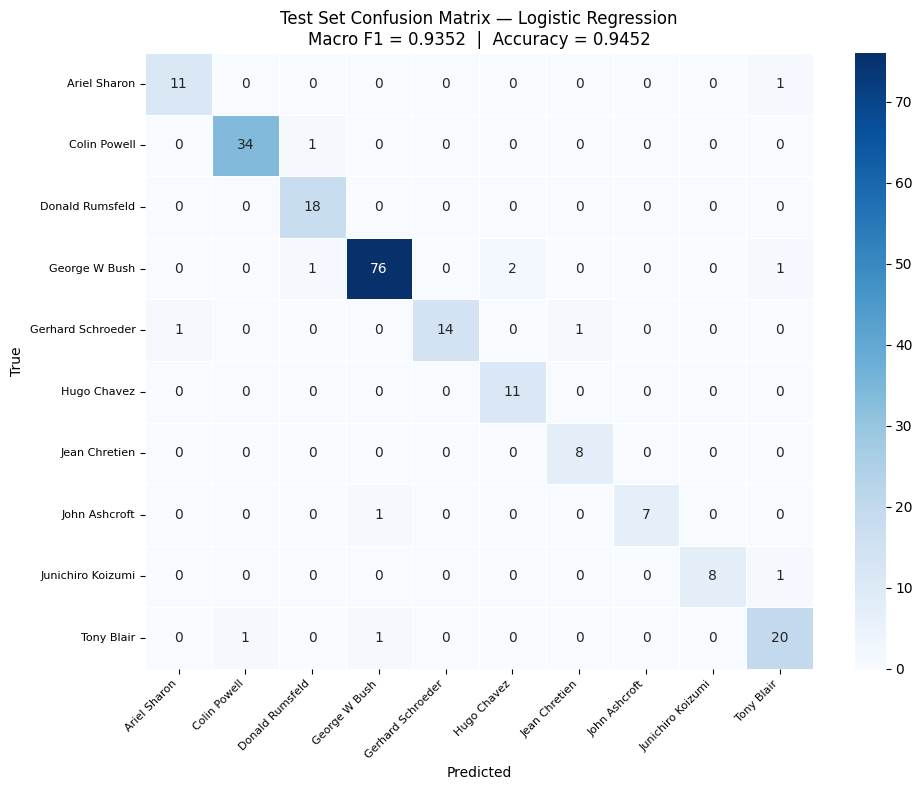

In [23]:
# Final test set confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            linewidths=0.5)
plt.title(f"Test Set Confusion Matrix — {best_name}\n"
          f"Macro F1 = {test_f1:.4f}  |  Accuracy = {test_acc:.4f}",
          fontsize=12)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(VISUALS_PATH, "07_test_confusion_matrix.png"), dpi=150, bbox_inches='tight')
print("Saved: Visuals/07_test_confusion_matrix.png")
plt.show()


Saved: Visuals/08_per_class_f1.png


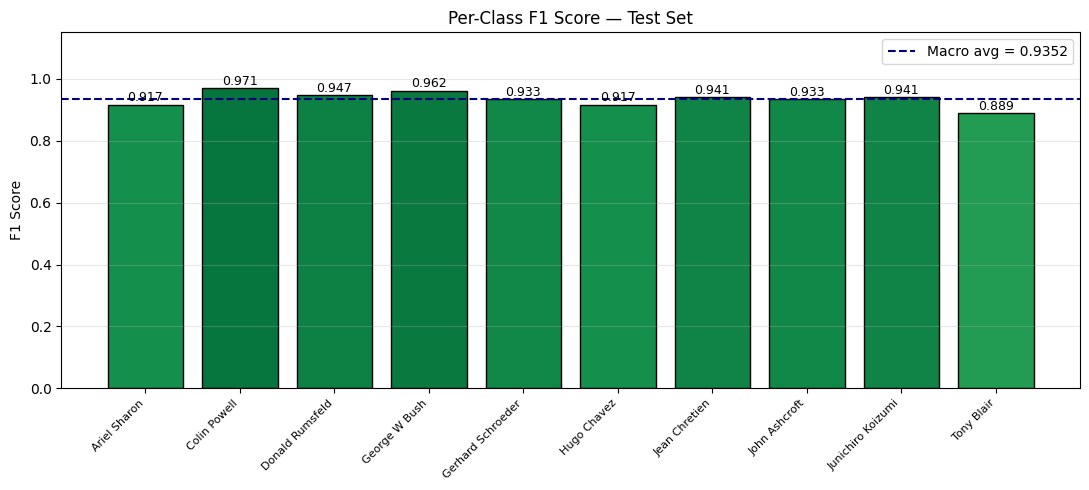

In [24]:
# Per-class F1 bar chart
per_class_f1 = f1_score(y_test, y_test_pred, average=None)

plt.figure(figsize=(11, 5))
bars = plt.bar(short_names, per_class_f1,
               color=plt.cm.RdYlGn(per_class_f1),
               edgecolor='black')

for bar, val in zip(bars, per_class_f1):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{val:.3f}", ha='center', fontsize=9)

plt.axhline(test_f1, color='navy', linestyle='--',
            label=f"Macro avg = {test_f1:.4f}")
plt.title("Per-Class F1 Score — Test Set", fontsize=12)
plt.ylabel("F1 Score")
plt.ylim(0, 1.15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(VISUALS_PATH, "08_per_class_f1.png"), dpi=150, bbox_inches='tight')
print("Saved: Visuals/08_per_class_f1.png")
plt.show()


## 16. Save the Model

In [25]:
os.makedirs("artifacts", exist_ok=True)

class_dict = {name: idx for idx, name in enumerate(class_names)}

joblib.dump(best_model, "artifacts/saved_model.pkl")
with open("artifacts/class_dictionary.json", "w") as f:
    json.dump(class_dict, f, indent=4)

print("Model saved to artifacts/saved_model.pkl")
print("Class dictionary saved to artifacts/class_dictionary.json")
print("\nClass dictionary:", class_dict)


Model saved to artifacts/saved_model.pkl
Class dictionary saved to artifacts/class_dictionary.json

Class dictionary: {'Ariel_Sharon': 0, 'Colin_Powell': 1, 'Donald_Rumsfeld': 2, 'George_W_Bush': 3, 'Gerhard_Schroeder': 4, 'Hugo_Chavez': 5, 'Jean_Chretien': 6, 'John_Ashcroft': 7, 'Junichiro_Koizumi': 8, 'Tony_Blair': 9}


## 17. Predict on a New Image

In [26]:
def predict_person(image_path, threshold=REJECTION_THRESHOLD):
    # load model and class dict
    model = joblib.load("artifacts/saved_model.pkl")
    with open("artifacts/class_dictionary.json") as f:
        class_dict = json.load(f)
    idx_to_name = {v: k for k, v in class_dict.items()}

    # read and preprocess image
    img = cv2.imread(image_path)
    if img is None:
        print("Could not read image")
        return

    face = get_face(img)
    face = cv2.resize(face, (224, 224))
    face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
    face = preprocess_input(np.expand_dims(face.astype(np.float32), axis=0))
    emb  = embedding_model.predict(face, verbose=0)

    # predict
    probs    = model.predict_proba(emb)[0]
    max_conf = float(probs.max())
    pred_idx = int(probs.argmax())
    pred_name = idx_to_name[pred_idx]

    if max_conf < threshold:
        result = "Unknown"
    else:
        result = pred_name

    print(f"Predicted : {result}")
    print(f"Confidence: {max_conf:.4f}  (threshold = {threshold:.3f})")
    print(f"Top 3 predictions:")
    top3 = sorted(enumerate(probs), key=lambda x: -x[1])[:3]
    for idx, prob in top3:
        print(f"  {idx_to_name[idx]:<25} {prob:.4f}")

    return result


# Example usage:
# predict_person("path/to/some/image.jpg")
print("predict_person() is ready to use")


predict_person() is ready to use
